## Plots for the group project


In [61]:
import plotters as pl
import pandas as pd
import numpy as np
import helper_functions as hf
import matplotlib.pyplot as plt
import importlib
importlib.reload(pl)


<module 'plotters' from 'e:\\Group Project\\group_project\\Vlads Plot\\plotters.py'>

In [55]:
cv_prm_df_t = pd.read_csv("datasets/cv_prm_t.csv")
cv_prm_df_n = pd.read_csv("datasets/cv_prm_n.csv")

vv_prm_df_t = pd.read_csv("datasets/vv_prm_t.csv")
vv_prm_df_n = pd.read_csv("datasets/vv_prm_n.csv")

cv_rft_df_t = pd.read_csv("datasets/cv_rft_t_3.8.csv")
cv_rft_df_n = pd.read_csv("datasets/cv_rft_n_3.8.csv")

vv_rft_df_t = pd.read_csv("datasets/vv_rft_t.csv")
vv_rft_df_n = pd.read_csv("datasets/vv_rft_n.csv")

bonferroni_df_t = pd.read_csv("datasets/bonferroni_t.csv")
bonferroni_df_n = pd.read_csv("datasets/bonferroni_n.csv")

### Data Cleaning

In [56]:
cv_prm_df_t["method"] = "Cluster-wise permutation"
cv_prm_df_t["distribution"] = "t"

cv_prm_df_n["method"] = "Cluster-wise permutation"
cv_prm_df_n["distribution"] = "normal"


cv_rft_df_t["method"] = "Cluster-wise RFT"
cv_rft_df_t["distribution"] = "t"

cv_rft_df_n["method"] = "Cluster-wise RFT"
cv_rft_df_n["distribution"] = "normal"

vv_prm_df_t["method"] = "Voxel-wise permutation"
vv_prm_df_t["distribution"] = "t"

vv_prm_df_n["method"] = "Voxel-wise permutation"
vv_prm_df_n["distribution"] = "normal"

cv_rft_df_n.rename(columns={"n_subj" : "n", "FWER" : "fwer"}, inplace=True)
cv_rft_df_t.rename(columns={"n_subj" : "n", "FWER" : "fwer"}, inplace=True)

cv_rft_df_n.drop(['FWHM','threshold_u'],axis=1, inplace=True)
cv_rft_df_t.drop(['FWHM','threshold_u'],axis=1, inplace=True)

final_metrics_df_t = pd.concat([cv_prm_df_t, vv_prm_df_t, vv_rft_df_t, cv_rft_df_t, bonferroni_df_t], ignore_index=True)
final_metrics_df_n = pd.concat([cv_prm_df_n, vv_prm_df_n, vv_rft_df_n, cv_rft_df_n, bonferroni_df_n], ignore_index=True)
final_metrics_df_n.head()

,fwer,sensitivity,sm_sigma,snr,n,method,distribution
0,0.0,0.0,0.0,0.00,2,Cluster-wise permutation,normal
1,0.0,0.0,0.0,0.10,2,Cluster-wise permutation,normal
2,0.0,0.0,0.0,0.25,2,Cluster-wise permutation,normal
3,0.0,0.0,0.0,0.50,2,Cluster-wise permutation,normal
4,0.0,0.0,0.0,0.75,2,Cluster-wise permutation,normal


In [57]:
# bonferroni_df_t.head()
# cv_rft_df_n.head()
# vv_prm_df_n.head()
# vv_rft_df_n.head()

### Generate 3*2 Plot

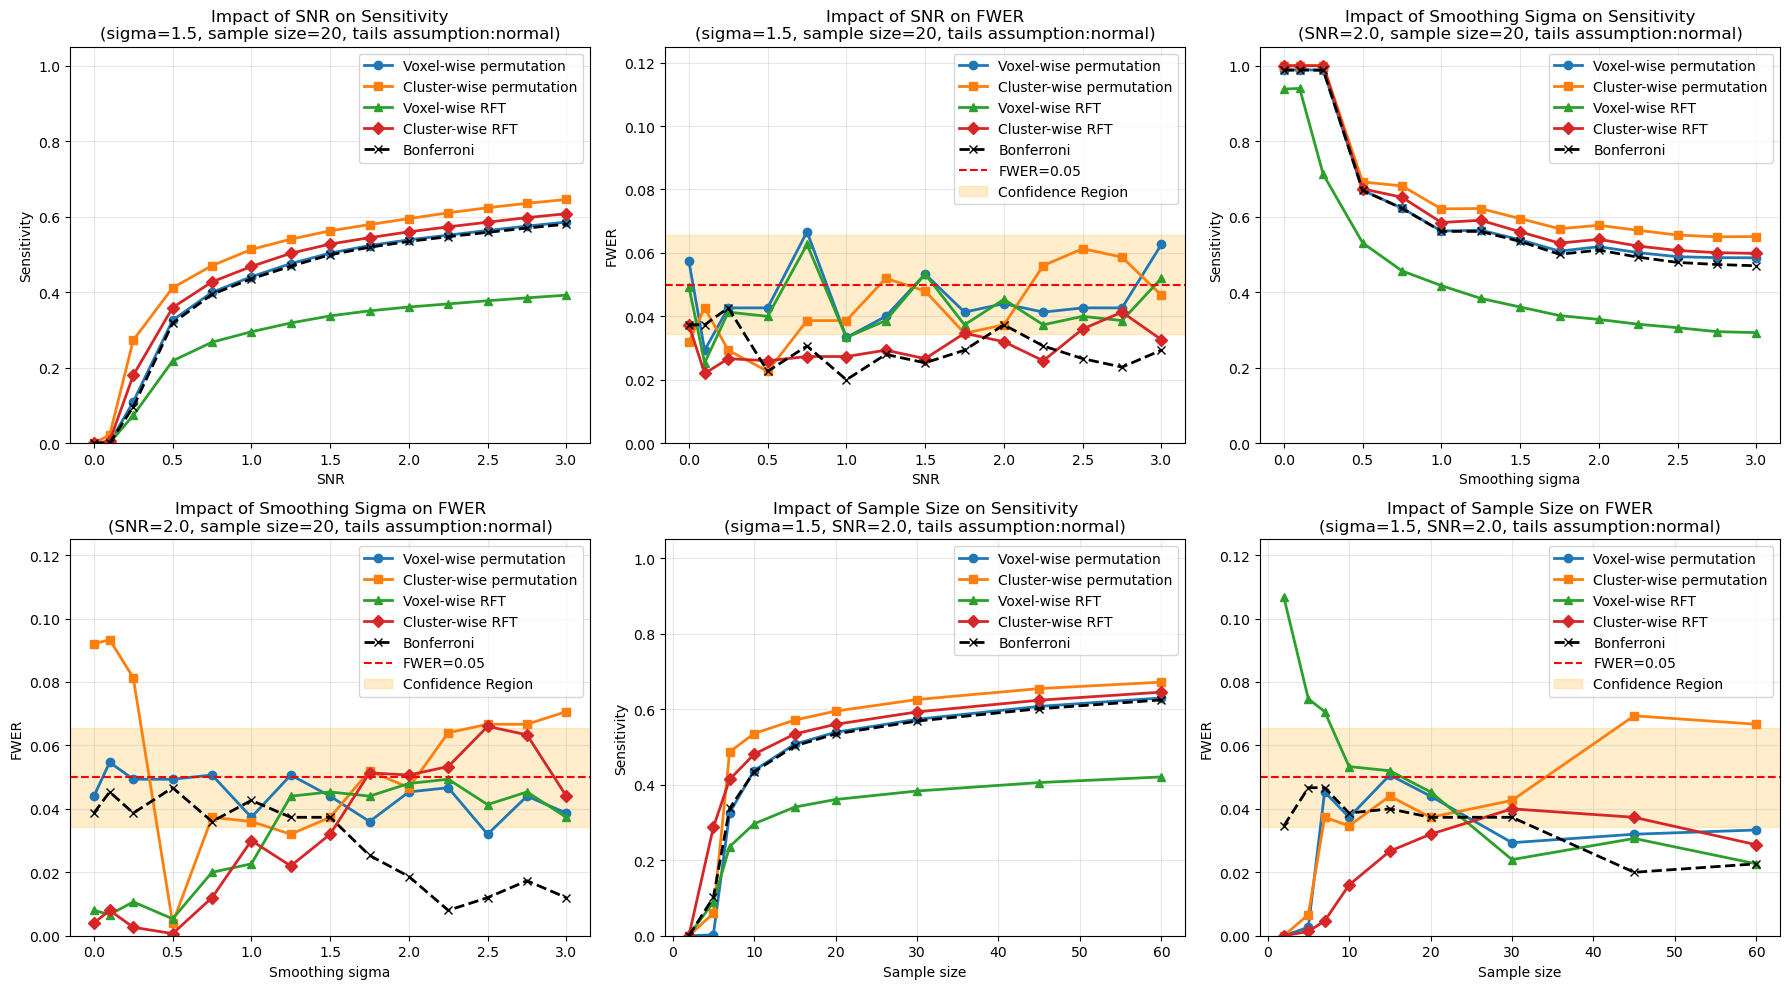

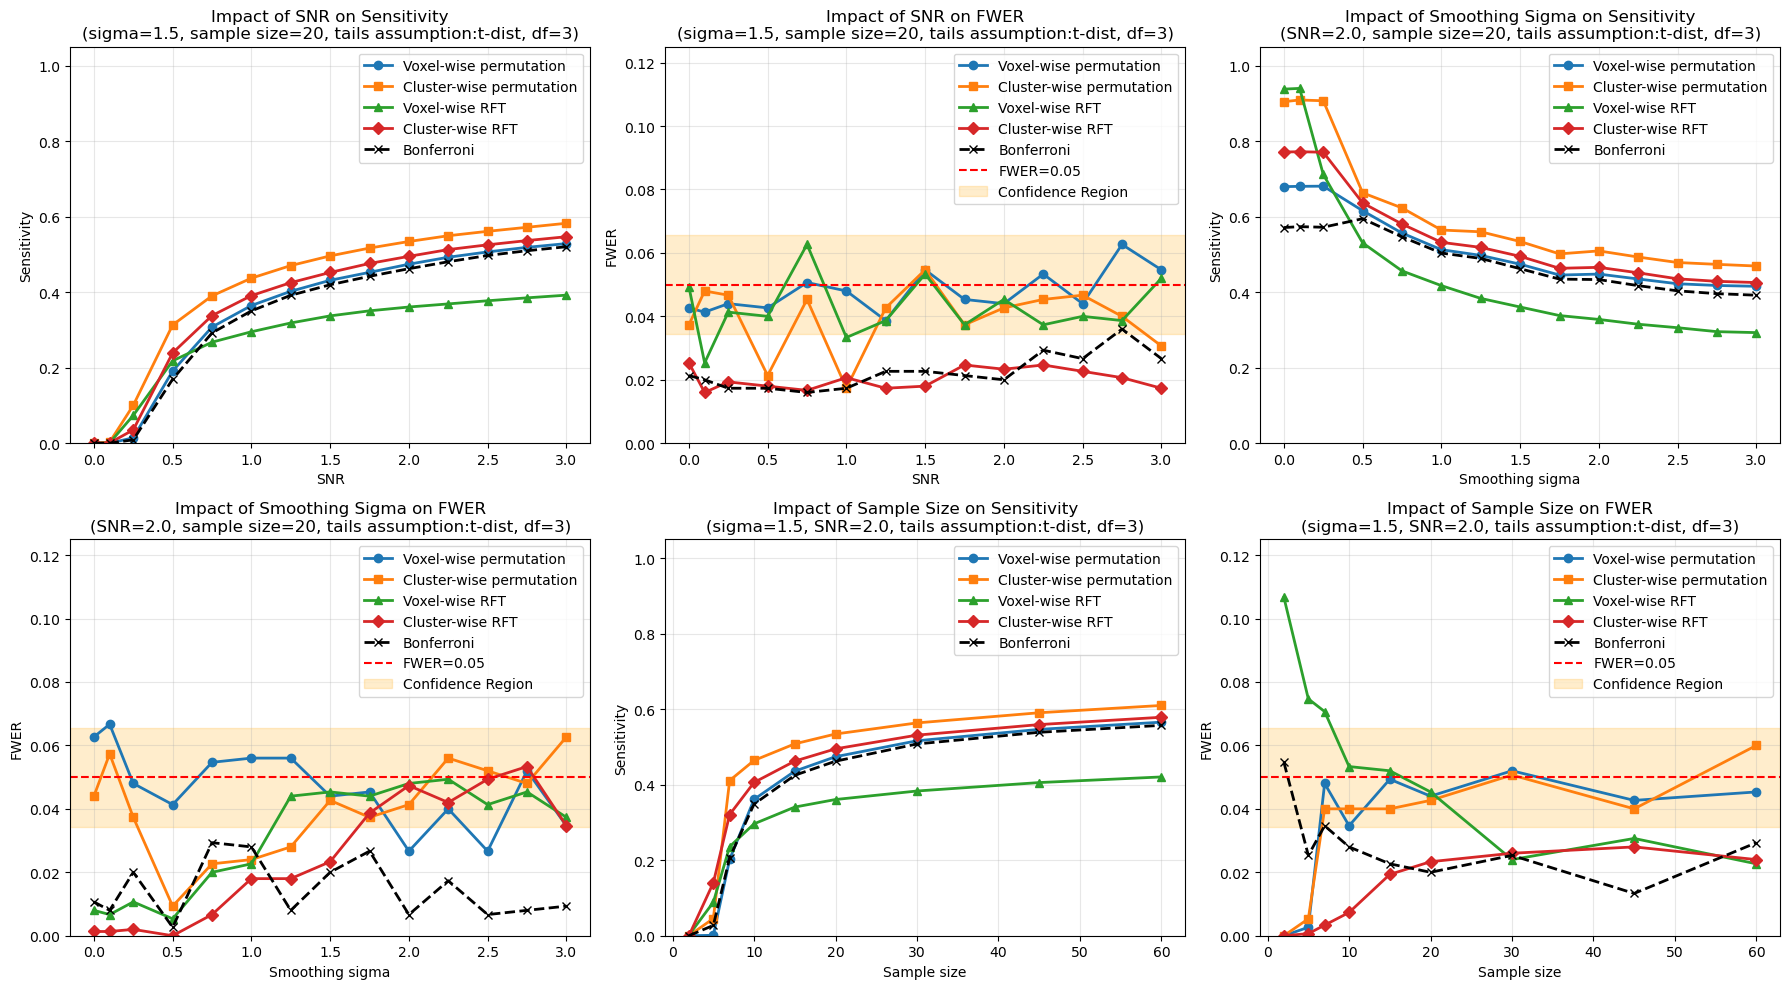

In [59]:
import importlib
import plotters as pl
importlib.reload(pl)

test_snrs =     [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
test_sigmas =   [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
n_values = [2,5,7,10,15,20,30,45,60]

# Calculate CI region for the plots
fwer = 0.05
z_score = 1.96
n_sim = 750
CI_region = z_score * (0.05 * (1 - 0.05) / n_sim) **0.5

pl.plot_all_method_curves(final_metrics_df_n, sigma=1.5, snr_val=2.0, n_val=20, CI_region=CI_region)
pl.plot_all_method_curves(final_metrics_df_t, sigma=1.5, snr_val=2.0, n_val=20, CI_region=CI_region)

### Generate single Plots

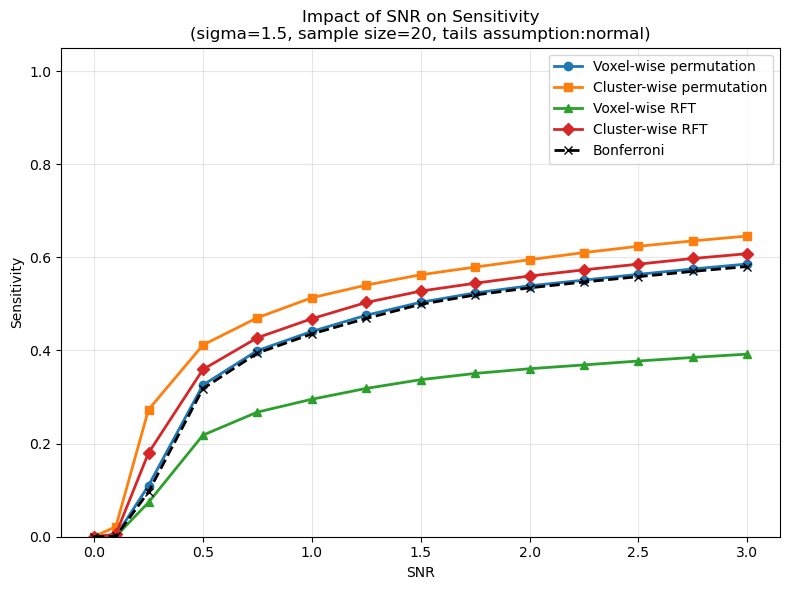

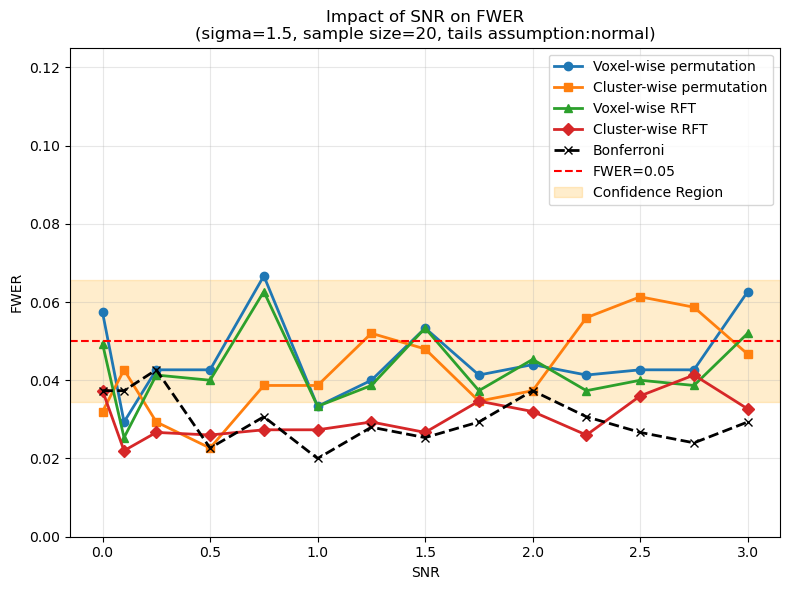

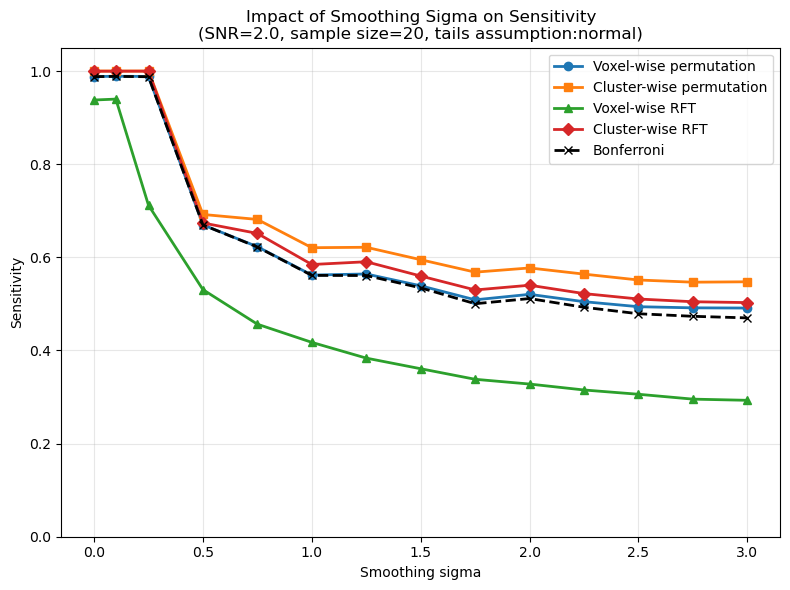

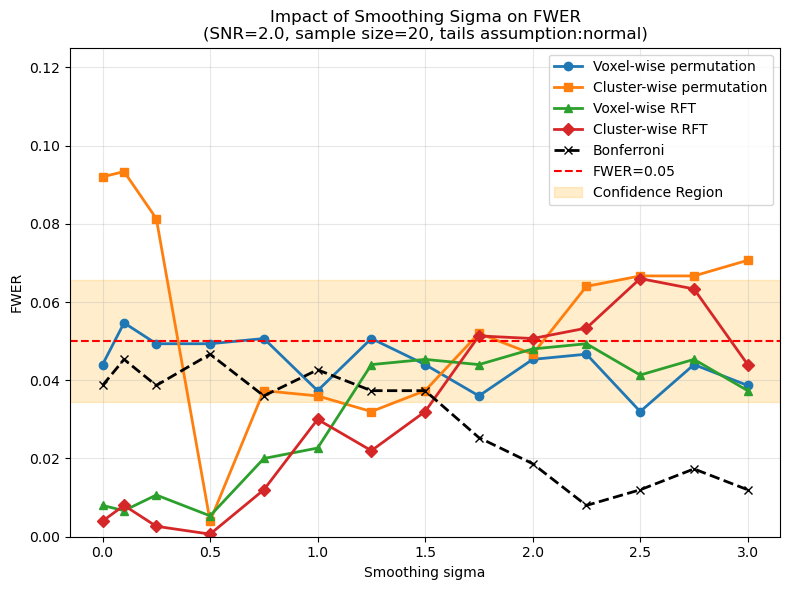

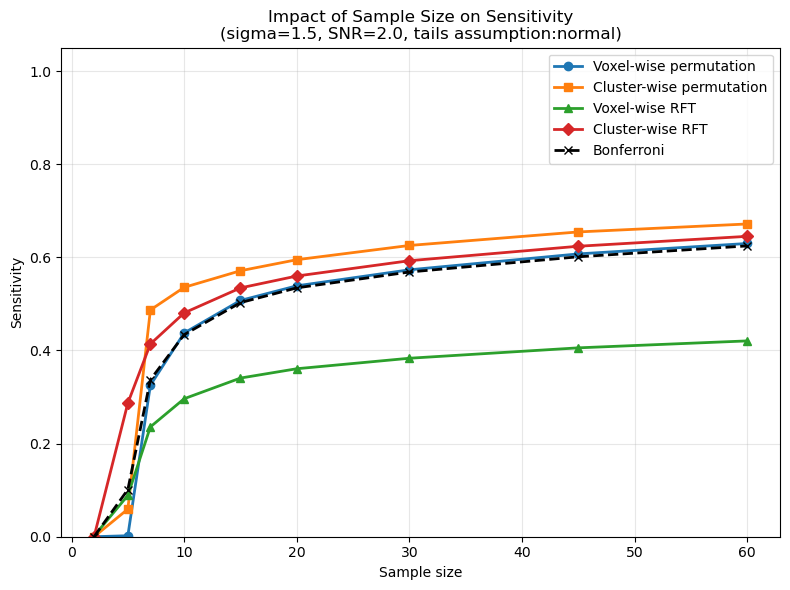

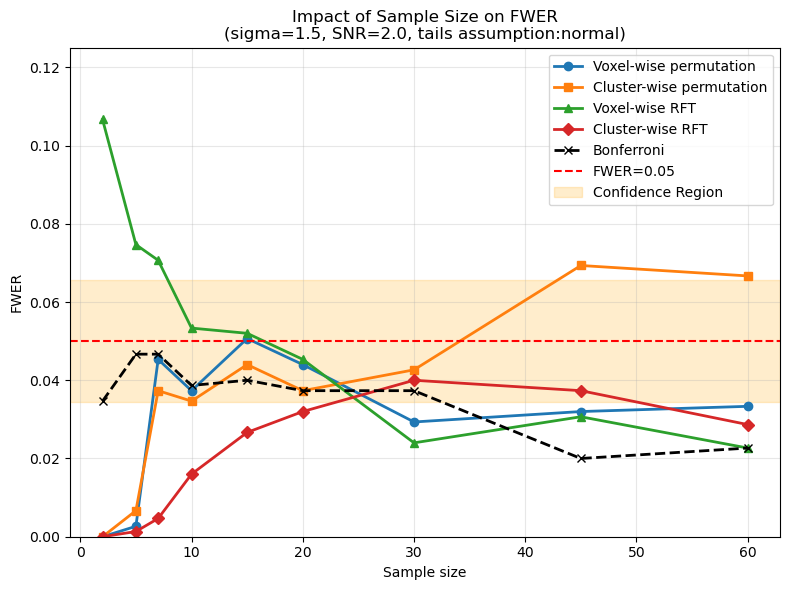

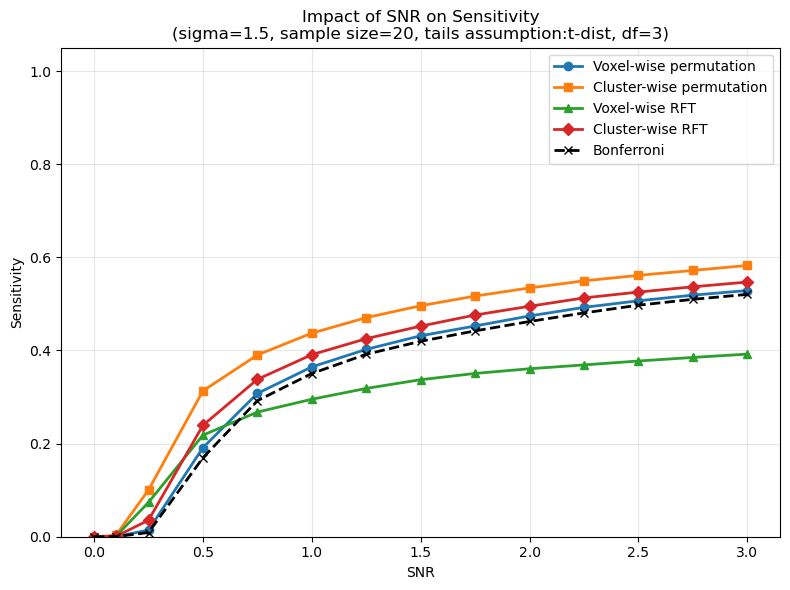

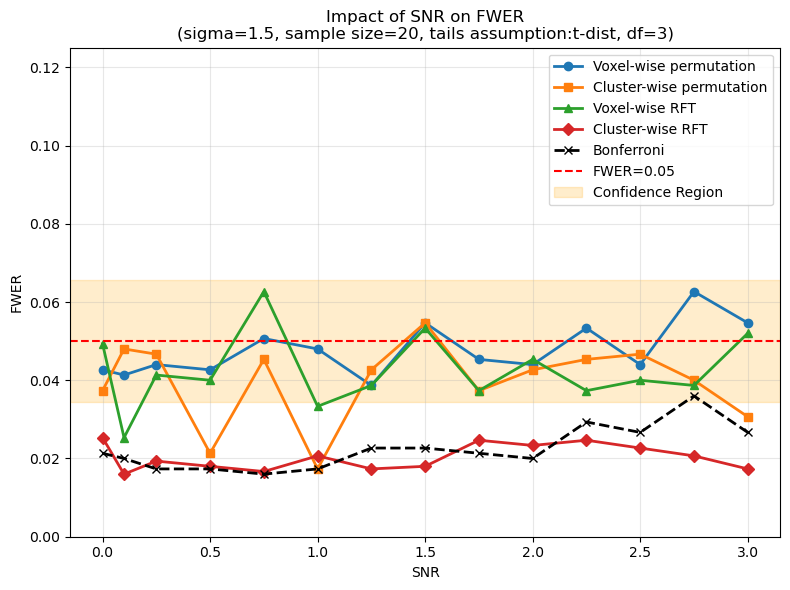

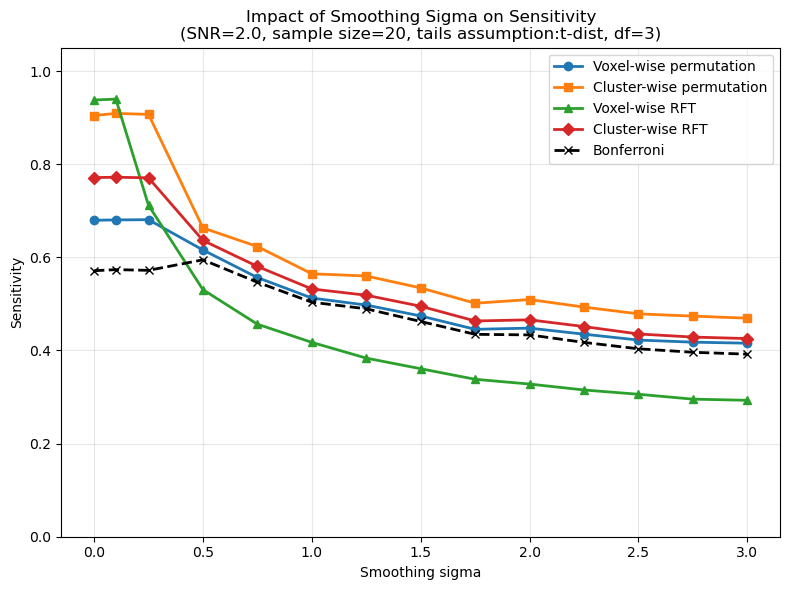

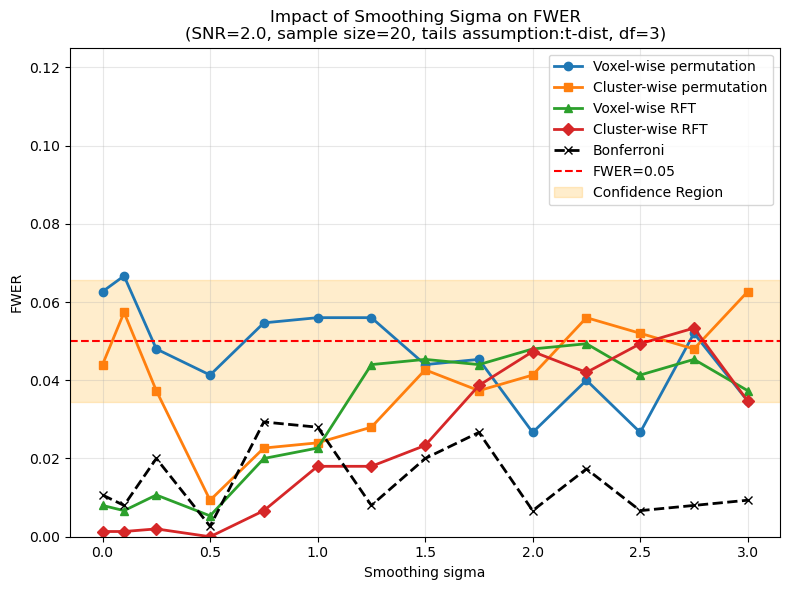

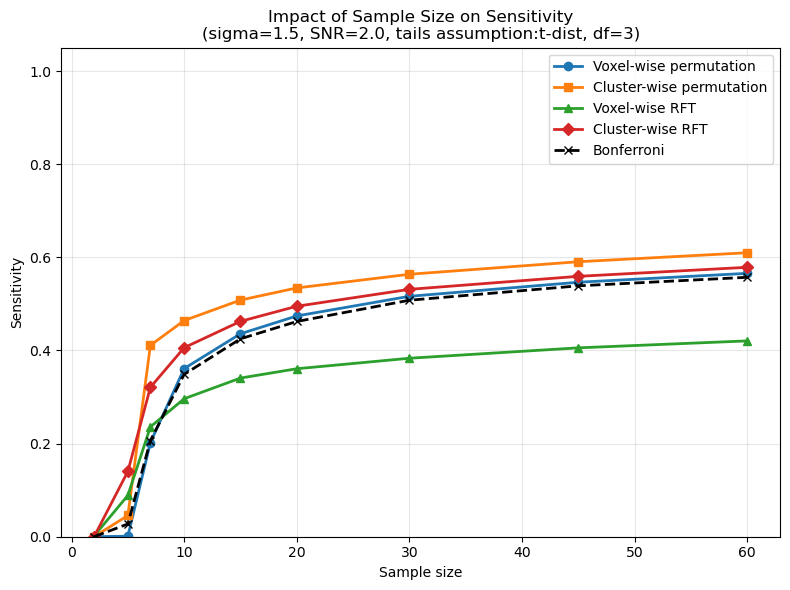

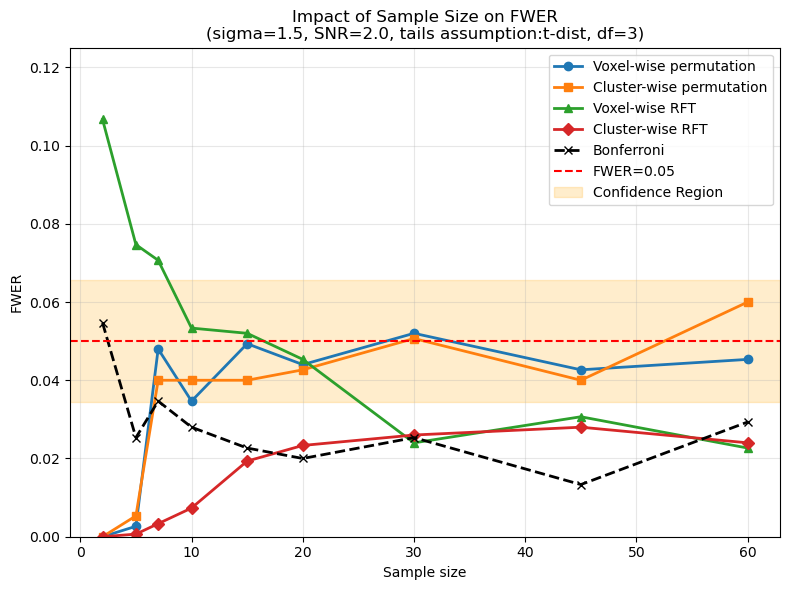

In [64]:
sigma = 1.5
snr_val = 2.0
n_val = 20
CI_region = 1.96 * (0.05 * 0.95 / 750) ** 0.5

datasets = [
    (final_metrics_df_n, "normal"),
    (final_metrics_df_t, "t"),
]

plots = [
    ("sensitivity_vs_snr",   lambda df, ax: pl.plot_sensitivity_vs_snr(df, sigma=sigma, n_val=n_val, ax=ax)),
    ("fwer_vs_snr",          lambda df, ax: pl.plot_fwer_vs_snr(df, sigma=sigma, n_val=n_val, ax=ax, CI_region=CI_region)),
    ("sensitivity_vs_sigma", lambda df, ax: pl.plot_sensitivity_vs_sigma(df, snr_val=snr_val, n_val=n_val, ax=ax)),
    ("fwer_vs_sigma",        lambda df, ax: pl.plot_fwer_vs_sigma(df, snr_val=snr_val, n_val=n_val, ax=ax, CI_region=CI_region)),
    ("sensitivity_vs_n",     lambda df, ax: pl.plot_sensitivity_vs_n(df, sigma=sigma, snr_val=snr_val, ax=ax)),
    ("fwer_vs_n",            lambda df, ax: pl.plot_fwer_vs_n(df, sigma=sigma, snr_val=snr_val, ax=ax, CI_region=CI_region)),
]

for df, suffix in datasets:
    for name, plot_fn in plots:
        fig, ax = plt.subplots(figsize=(8, 6))
        plot_fn(df, ax)
        plt.tight_layout()
        fig.savefig(f"Output_plot/{name}_{suffix}.png", dpi=300, bbox_inches="tight")
        plt.show()

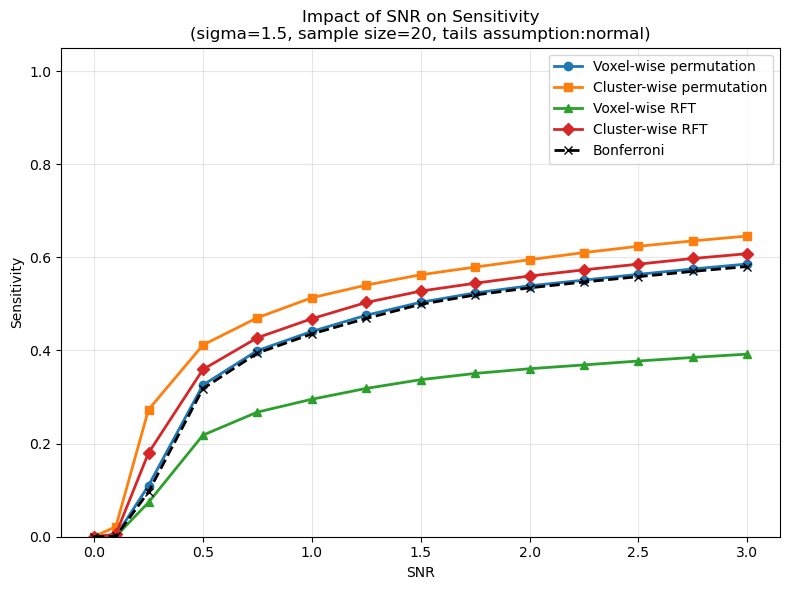

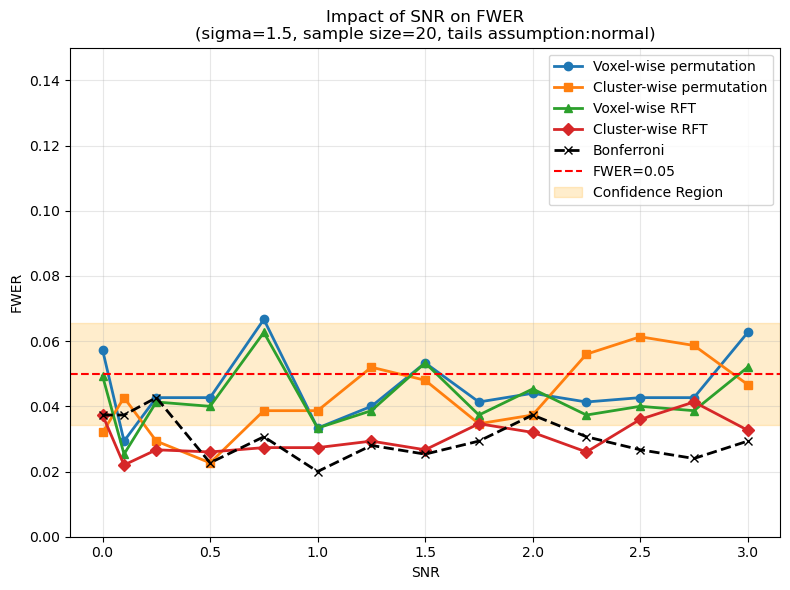

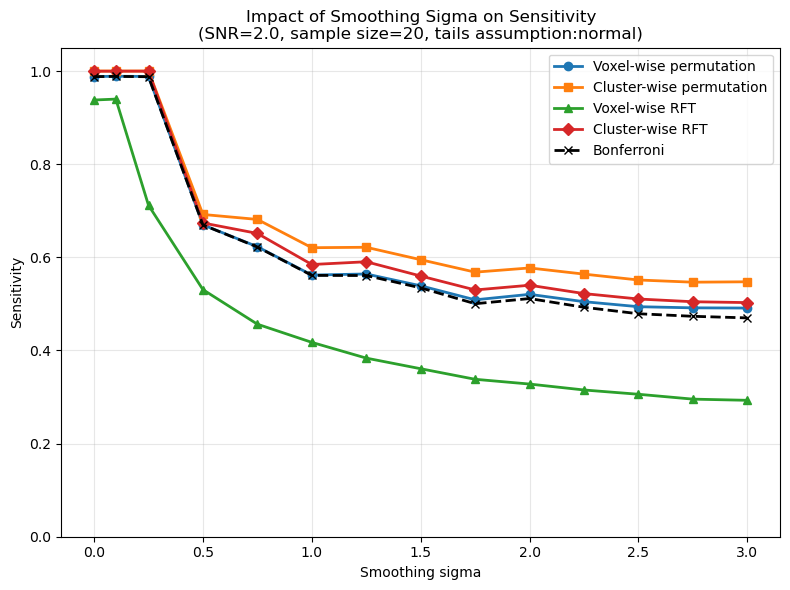

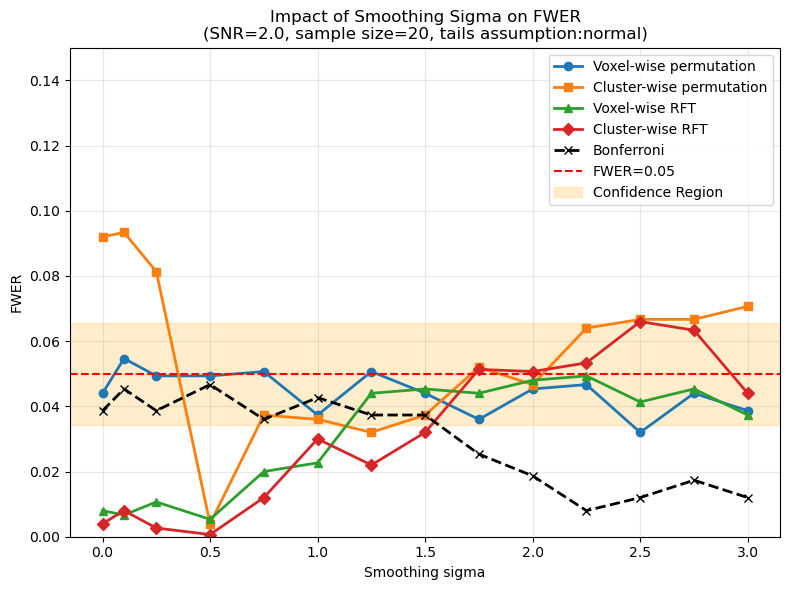

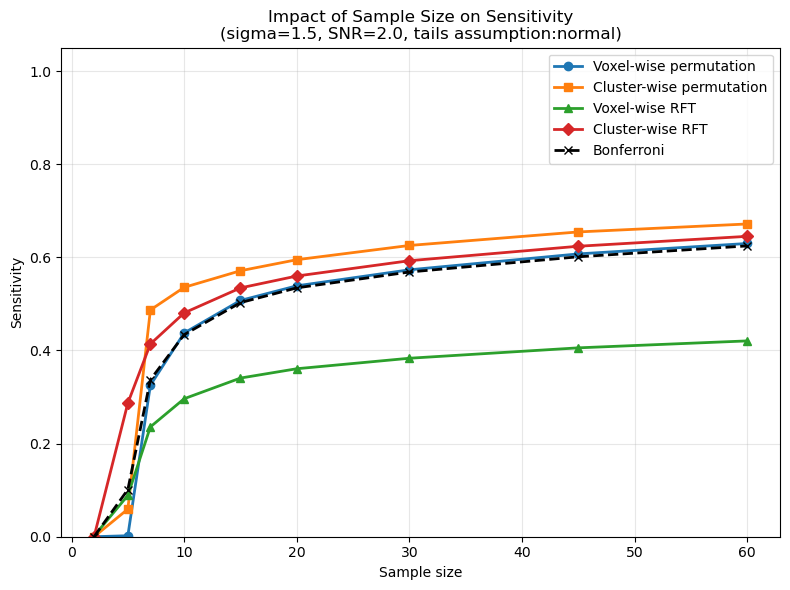

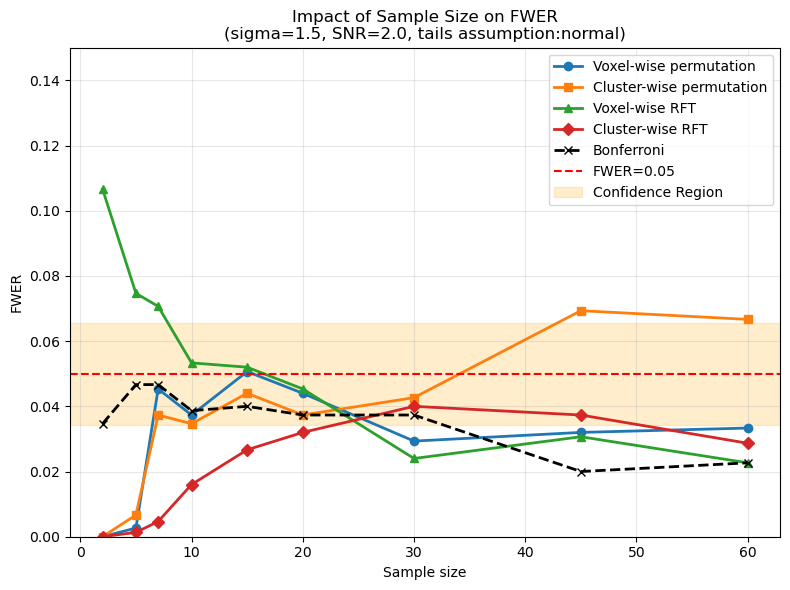

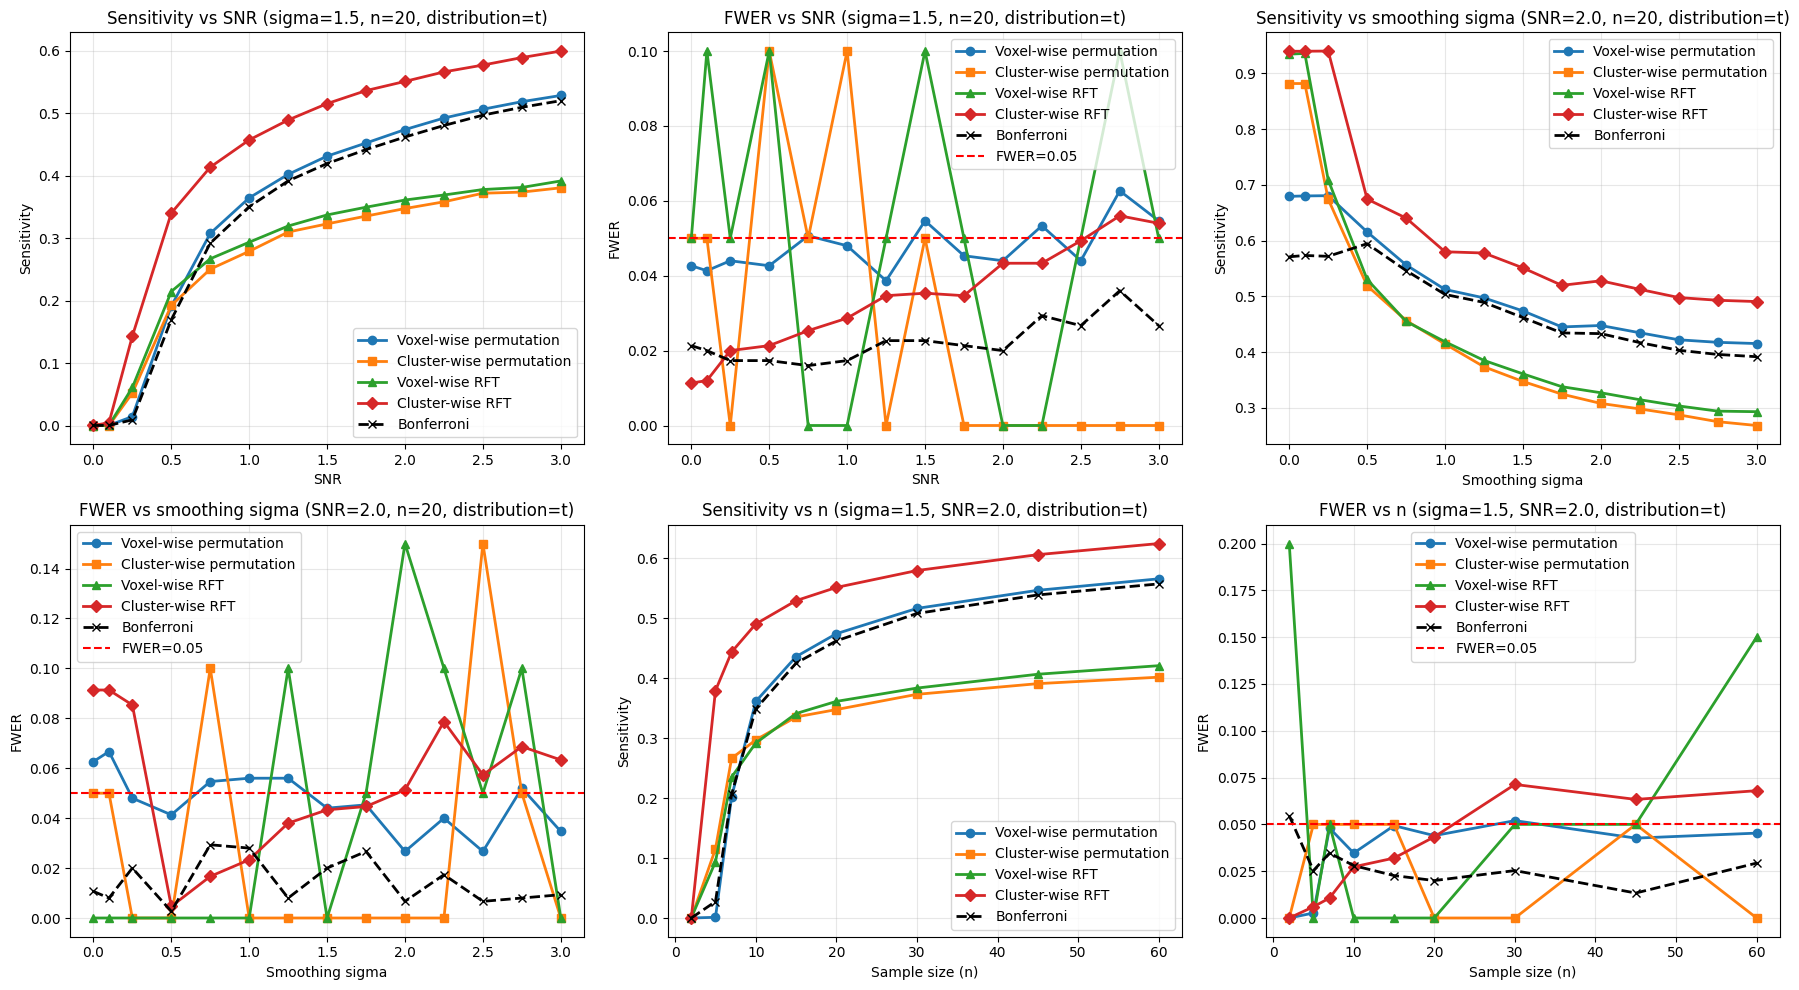

In [11]:
import importlib
import plotters as pl
importlib.reload(pl)

pl.plot_all_method_curves(final_metrics_df_t, sigma=1.5, snr_val=2.0, n_val=20)

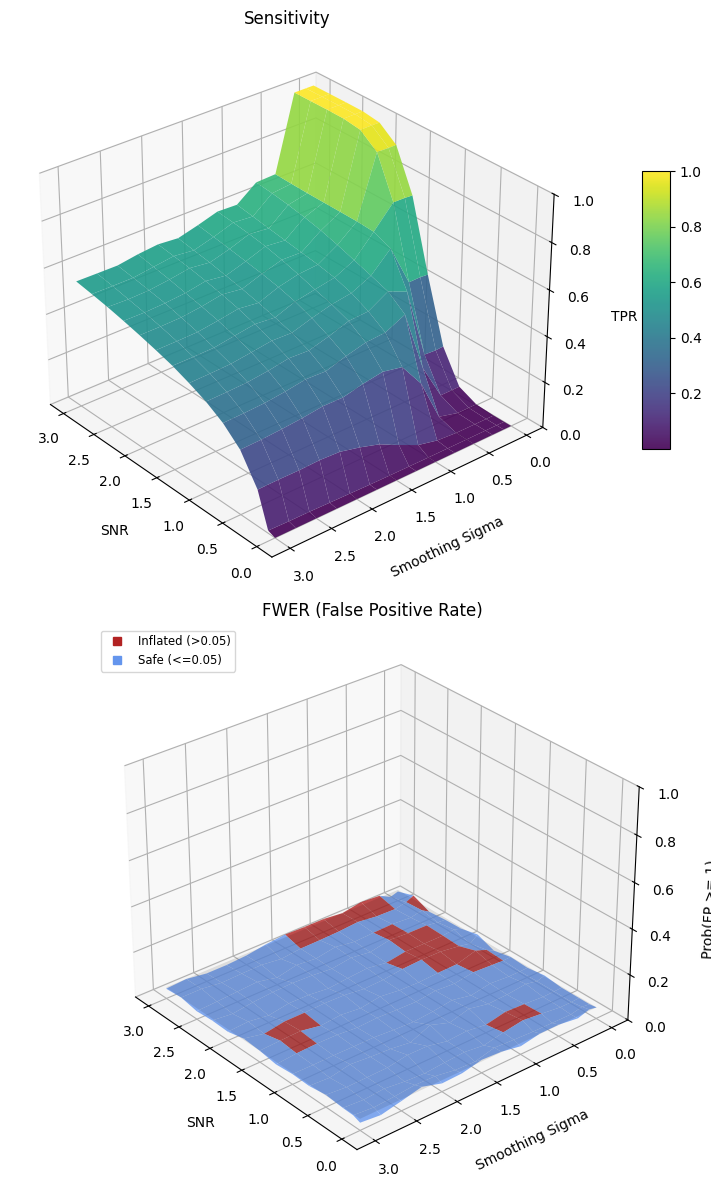

In [12]:
sens_mat, fwer_mat = hf.reconstruct_metric_matrices(df = vv_prm_df_n, n_value = 20, sigma_levels = test_sigmas, snr_levels = test_snrs, method = "Voxel-wise permutation")
pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)